In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore') # Tắt cảnh báo để kết quả hiển thị gọn gàng


# BƯỚC 1 & 2: NẠP DỮ LIỆU & FEATURE ENGINEERING

print("1. Đang nạp và xử lý dữ liệu...")
file_path = '/content/Banking_Transactional_Dataset.xlsx'
df = pd.read_excel(file_path)

# Trích xuất đặc trưng thời gian
df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.month
df['DayOfWeek'] = df['TransactionDate'].dt.dayofweek

# Loại bỏ các cột không có giá trị dự báo
cols_to_drop = ['TransactionID', 'CustomerID', 'TransactionDate', 'BranchLat', 'BranchLong', 'Currency']
df_ml = df.drop(columns=cols_to_drop)


# BƯỚC 3 & 4: ENCODING & TRAIN/TEST SPLIT

X = df_ml.drop(columns=['Amount'])
y = df_ml['Amount'] # Giữ nguyên gốc, KHÔNG dùng np.log1p

# Mã hóa One-Hot cho các cột dạng chữ
X_encoded = pd.get_dummies(X, drop_first=True)

# Chia tập dữ liệu 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


# BƯỚC 5: DATA SCALING (CHUẨN HÓA THANG ĐO)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# BƯỚC 6: CROSS VALIDATION & HYPERPARAMETER TUNING

print("2. Đang Tuning tìm siêu tham số tối ưu (Quá trình này mất khoảng 2-3 phút)...\n")
final_results = []
best_models = {}

# --- 6.1. Linear Regression (Mốc tham chiếu mặc định) ---
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
final_results.append({
    "Mô hình": "Linear Regression",
    "MAE": mean_absolute_error(y_test, y_pred_lr),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    "R² Score": r2_score(y_test, y_pred_lr)
})

# --- 6.2. XGBoost (Tuning với Cross Validation) ---
xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, objective='reg:squarederror'),
    param_distributions=xgb_params, n_iter=5, cv=3, scoring='r2', random_state=42, n_jobs=-1
)
xgb_search.fit(X_train_scaled, y_train)
best_xgb = xgb_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_scaled)
final_results.append({
    "Mô hình": "XGBoost (Tối ưu)",
    "MAE": mean_absolute_error(y_test, y_pred_xgb),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
    "R² Score": r2_score(y_test, y_pred_xgb)
})
best_models['XGBoost'] = best_xgb

# --- 6.3. Random Forest (Tuning với Cross Validation) ---
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None]
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=rf_params, n_iter=3, cv=3, scoring='r2', random_state=42, n_jobs=-1
)
rf_search.fit(X_train_scaled, y_train)
best_rf = rf_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
final_results.append({
    "Mô hình": "Random Forest (Tối ưu)",
    "MAE": mean_absolute_error(y_test, y_pred_rf),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    "R² Score": r2_score(y_test, y_pred_rf)
})
best_models['Random Forest'] = best_rf

results_df = pd.DataFrame(final_results)
display(results_df)

# In thêm bộ tham số tốt nhất mà cỗ máy Random Forest vừa tìm được
print("\nTham số vô địch của Random Forest:", rf_search.best_params_)

1. Đang nạp và xử lý dữ liệu...
2. Đang Tuning tìm siêu tham số tối ưu (Quá trình này mất khoảng 2-3 phút)...



,Mô hình,MAE,RMSE,R² Score
0,Linear Regression,2535.243003,3075.489292,0.247237
1,XGBoost (Tối ưu),2535.372439,3081.523955,0.244280
2,Random Forest (Tối ưu),2551.627106,3108.654519,0.230914



Tham số vô địch của Random Forest: {'n_estimators': 200, 'max_depth': 10}


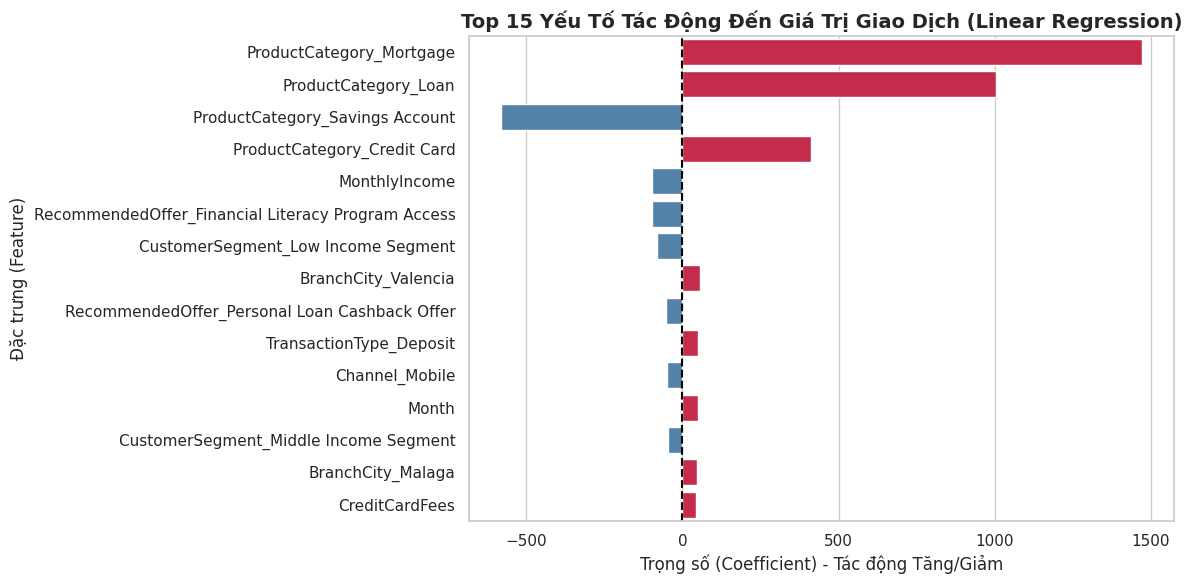


--- PHƯƠNG TRÌNH HỒI QUY (Minh họa Top 3 đặc trưng) ---
Amount = 5042.08 + 1470.99 * ProductCategory_Mortgage + 1005.42 * ProductCategory_Loan - 581.66 * ProductCategory_Savings Account + ...


In [6]:
# BƯỚC 7: TRỰC QUAN HÓA TRỌNG SỐ (MỨC ĐỘ ẢNH HƯỞNG) CỦA LINEAR REGRESSION

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Lấy mô hình Linear Regression đã huấn luyện ở BƯỚC 6 (biến lr)
# Tạo DataFrame chứa tên đặc trưng và trọng số (Coefficient)
coefficients = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': lr.coef_
})

# Lấy giá trị tuyệt đối để tìm ra top các đặc trưng tác động MẠNH NHẤT (bất kể âm hay dương)
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
top_features = coefficients.sort_values(by='Abs_Coefficient', ascending=False).head(15)

# --- PHẦN ĐÃ SỬA LỖI ---
# Tạo một danh sách màu (list) thay vì Pandas Series
colors = top_features['Coefficient'].apply(lambda x: 'crimson' if x > 0 else 'steelblue').tolist()

# Vẽ biểu đồ: Màu đỏ nếu làm tăng Amount (hệ số dương), màu xanh nếu làm giảm Amount (hệ số âm)
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=top_features,
    palette=colors,
    hue='Feature',  # Thêm hue để tương thích với Seaborn bản mới
    legend=False    # Ẩn chú giải vì không cần thiết
)
# -----------------------

plt.title('Top 15 Yếu Tố Tác Động Đến Giá Trị Giao Dịch (Linear Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Trọng số (Coefficient) - Tác động Tăng/Giảm', fontsize=12)
plt.ylabel('Đặc trưng (Feature)', fontsize=12)

# Kẻ một đường line ở số 0 để dễ phân biệt
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()

# In phương trình hồi quy trực quan để đưa vào báo cáo
print("\n--- PHƯƠNG TRÌNH HỒI QUY (Minh họa Top 3 đặc trưng) ---")
top_3 = top_features.head(3)
formula = f"Amount = {lr.intercept_:.2f}"
for index, row in top_3.iterrows():
    sign = " + " if row['Coefficient'] > 0 else " - "
    formula += f"{sign}{abs(row['Coefficient']):.2f} * {row['Feature']}"
formula += " + ..."
print(formula)